In [1]:
import os
from PIL import Image

# 1. Setup paths
input_dir = 'D:\\landslide\\Feature_Visuals'  # Change this to your folder
files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])[:14]

def save_grid(image_list, output_name):
    if not image_list: return
    
    # Open images and ensure they are the same size
    imgs = [Image.open(os.path.join(input_dir, f)) for f in image_list]
    w, h = imgs[0].size
    
    # Create blank transparent canvas for 2x2 grid
    grid_img = Image.new('RGBA', (w * 2, h * 2), (255, 255, 255, 0))
    
    # Define 2x2 coordinates
    positions = [(0, 0), (w, 0), (0, h), (w, h)]
    
    for i, img in enumerate(imgs):
        # Resize if necessary to match the first image's dimensions
        if img.size != (w, h):
            img = img.resize((w, h), Image.Resampling.LANCZOS)
        grid_img.paste(img, positions[i])
        
    grid_img.save(output_name)
    print(f"Saved: {output_name}")

# 2. Split into two groups of 7
# Group A: Features 1-4 (Full 2x2) and 5-7 (1 empty spot)
# Slide 1 (Features 1-4)
save_grid(files[0:4], 'LSM_Grid_1_Part1.png')
# Slide 1 (Features 5-7)
save_grid(files[4:7], 'LSM_Grid_1_Part2.png')

# Slide 2 (Features 8-11)
save_grid(files[7:11], 'LSM_Grid_2_Part1.png')
# Slide 2 (Features 12-14)
save_grid(files[11:14], 'LSM_Grid_2_Part2.png')

Saved: LSM_Grid_1_Part1.png
Saved: LSM_Grid_1_Part2.png
Saved: LSM_Grid_2_Part1.png
Saved: LSM_Grid_2_Part2.png


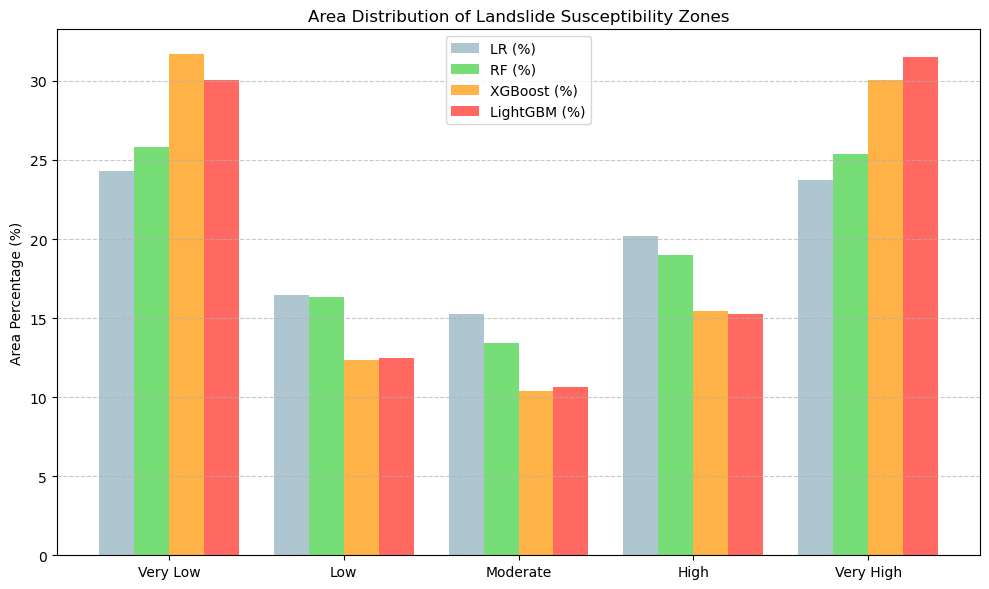

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
zones = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
lr = [24.31, 16.48, 15.28, 20.20, 23.71]
rf = [25.85, 16.34, 13.45, 18.96, 25.37]
xgboost = [31.68, 12.38, 10.40, 15.43, 30.08]
lgbm = [30.08, 12.50, 10.65, 15.26, 31.49]

x = np.arange(len(zones))  # Label locations
width = 0.2  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
ax.bar(x - 1.5*width, lr, width, label='LR (%)', color='#aec6cf')
ax.bar(x - 0.5*width, rf, width, label='RF (%)', color='#77dd77')
ax.bar(x + 0.5*width, xgboost, width, label='XGBoost (%)', color='#ffb347')
ax.bar(x + 1.5*width, lgbm, width, label='LightGBM (%)', color='#ff6961')

# Add labels and formatting
ax.set_ylabel('Area Percentage (%)')
ax.set_title('Area Distribution of Landslide Susceptibility Zones')
ax.set_xticks(x)
ax.set_xticklabels(zones)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()